# Digital Payments Adoption in Europe
# What drives the shift away from cash?
This notebook explores digital payment adoption across European countries using data from
the World Bank Global Findex Database, GDP per capita, and internet penetration rates.
The analysis is structured in five parts: data loading, trend analysis, correlation
analysis, clustering, and actionable conclusions.

**Data sources:**
- World Bank Global Findex Database (digital payments adoption)
- World Bank GDP per capita (NY.GDP.PCAP.CD)
- World Bank Internet penetration (IT.NET.USER.ZS)

In [124]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Global chart settings — clean style for the entire notebook
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

# Check that all files are correctly uploaded
for f in os.listdir("/content"):
    print(f)

.config
API_NY.GDP.PCAP.CD_DS2_en_csv_v2_121663.csv
GlobalFindexDatabase2025.csv
API_IT.NET.USER.ZS_DS2_en_csv_v2_121585.csv
sample_data


## Part 1 — Data Loading and Cleaning

**Question: what does digital payment adoption look like across European countries,
and how clean is the data?**



In [125]:
# Load the Global Findex Database 2025
df_findex = pd.read_csv("/content/GlobalFindexDatabase2025.csv")

# Overview of the dataset structure
print("Dimensions:", df_findex.shape)
print("\nColumns:")
print(df_findex.columns.tolist())
print("\nFirst 3 rows:")
df_findex.head(3)

Dimensions: (8564, 437)

Columns:
['countrynewwb', 'codewb', 'year', 'pop_adult', 'regionwb24_hi', 'incomegroupwb24', 'group', 'group2', 'account_t_d', 'fiaccount_t_d', 'mobileaccount_t_d', 'borrow_any_t_d', 'fin4_d', 'dig_acc', 'fin11_2a', 'fin11a', 'fin11b', 'fin11c', 'fin11f', 'fin11d', 'fin11e', 'fin14a', 'fin14b', 'fin14c', 'fin14d', 'fin13_1a', 'fin13_1b', 'fin26a', 'fin26b', 'fin27a', 'fin27b', 'fin17f', 'fin17a_17a1_d', 'fin17a', 'fin17b', 'fin17c', 'fin22d', 'fin22e', 'fin22a_22a1_22g_d', 'fin22a', 'fin22a_1', 'fin22b', 'fin22c', 'fin24sav', 'fin24fam', 'fin24work', 'fin24bor', 'fin24sell', 'fin24other', 'fin24aVD', 'fin24aSD', 'fin24aND', 'fin24aSD_ND', 'fin24aP', 'fin24aN', 'fin24sav_SD_ND', 'fin24fam_SD_ND', 'fin24work_SD_ND', 'fin24bor_SD_ND', 'fin24sell_SD_ND', 'fin24other_SD_ND', 'fin24sav_VD', 'fin24fam_VD', 'fin24work_VD', 'fin24bor_VD', 'fin24sell_VD', 'fin24other_VD', 'fh1', 'fin28', 'fh2', 'fin29', 'fin31a_31b', 'fin30', 'fin31a', 'fin31b', 'fin31d', 'fin32_33_34a',

/tmp/ipykernel_1292/2296985356.py:2: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df_findex = pd.read_csv("/content/GlobalFindexDatabase2025.csv")


,countrynewwb,codewb,year,pop_adult,regionwb24_hi,incomegroupwb24,group,group2,account_t_d,fiaccount_t_d,...,con12m_s,con26lm_s,con12w_s,con2f_s,con13_s,con26m_s,con28lm_s,con5a_s,con17c_s,con32h_s
0,Afghanistan,AFG,2011,14575546.0,South Asia (excluding high income),Low income,all,all,0.090050,0.090050,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Albania,ALB,2011,2281010.0,Europe & Central Asia (excluding high income),Upper middle income,all,all,0.282681,0.282681,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Algeria,DZA,2011,26251587.0,Middle East & North Africa (excluding high inc...,Lower middle income,all,all,0.332861,0.332861,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [126]:
import os
for f in os.listdir("/content"):
    print(f)

.config
API_NY.GDP.PCAP.CD_DS2_en_csv_v2_121663.csv
GlobalFindexDatabase2025.csv
API_IT.NET.USER.ZS_DS2_en_csv_v2_121585.csv
sample_data


In [127]:
# Search for columns related to digital payments, mobile money and transactions
# Keywords cover the main concepts in the Findex dataset
payments_columns = [col for col in df_findex.columns
                     if any(keyword in col.lower()
                            for keyword in ["dig", "pay", "merchant", "mobile", "g20"])]

print("Potentially relevant columns:")
for col in payments_columns:
    print(col)

Potentially relevant columns:
mobileaccount_t_d
dig_acc
g20_made
g20_received
g20_any
merchant_pay


In [128]:
# Search for columns related to digital payments, mobile money, and transactions
# The keywords cover the main concepts in the Findex dataset
df_findex[["countrynewwb", "year", "g20_any"]].dropna().head(20)

,countrynewwb,year,g20_any
144,Afghanistan,2014,0.055705
145,Albania,2014,0.224609
146,Algeria,2014,0.278243
147,Angola,2014,0.250393
148,Argentina,2014,0.395543
149,Armenia,2014,0.122709
150,Australia,2014,0.973591
151,Austria,2014,0.936272
152,Azerbaijan,2014,0.204165
153,Bahrain,2014,0.701457


In [129]:
# Inspection of the target variable: g20_any
# Percentage of adults (15+) who made or received at least one digital payment

print("Unique values in 'year':", df_findex["year"].unique())
print("\nNumber of unique countries:", df_findex["countrynewwb"].nunique())
print("\nDescriptive statistics for g20_any:")
print(df_findex["g20_any"].describe())
print("\nMissing values in g20_any:", df_findex["g20_any"].isna().sum())

Unique values in 'year': [2011 2014 2017 2021 2022 2024]

Number of unique countries: 174

Descriptive statistics for g20_any:
count    6152.000000
mean        0.532412
std         0.272287
min         0.012579
25%         0.304163
50%         0.499619
75%         0.768566
max         1.000000
Name: g20_any, dtype: float64

Missing values in g20_any: 2412


In [130]:
# Check unique values in 'group' and 'group2' columns
# to identify which value corresponds to the national aggregate (no demographic breakdown)
print("Unique values in 'group':")
print(df_findex["group"].unique())
print("\nUnique values in 'group2':")
print(df_findex["group2"].unique())

Unique values in 'group':
['all' 'gender' 'income' 'age_cat' 'urbanicity' 'laborforce' 'education']

Unique values in 'group2':
['all' 'men' 'women' 'richest 60%' 'poorest 40%' 'age 25+' 'ages 15-24'
 'rural' 'urban' 'out of laborforce' 'in laborforce'
 'secondary edu or more' 'prim edu or less']


In [131]:
# Selection of rows representing the national aggregate only,
# excluding demographic breakdowns (gender, income, age, etc.)
df_findex_national = df_findex[
    (df_findex["group"] == "all") & (df_findex["group2"] == "all")
].copy()

print("Dimensions after filter:", df_findex_national.shape)
print("\nNumber of unique countries:", df_findex_national["countrynewwb"].nunique())
print("\nAvailable years:", df_findex_national["year"].unique())

Dimensions after filter: (771, 437)

Number of unique countries: 174

Available years: [2011 2014 2017 2021 2022 2024]


In [132]:
# Check unique values in the region column
# to identify how European countries are labelled
print(df_findex_national["regionwb24_hi"].unique())

['South Asia (excluding high income)'
 'Europe & Central Asia (excluding high income)'
 'Middle East & North Africa (excluding high income)'
 'Sub-Saharan Africa (excluding high income)'
 'Latin America & Caribbean (excluding high income)' 'High income'
 'East Asia & Pacific (excluding high income)' nan]


In [133]:
# List of ISO3 country codes in scope for this analysis
# Definition: EU27 + UK + Norway + Switzerland + Iceland (EU + EFTA + UK)
europe_countries = [
    "AUT", "BEL", "BGR", "HRV", "CYP", "CZE", "DNK", "EST", "FIN", "FRA",
    "DEU", "GRC", "HUN", "IRL", "ITA", "LVA", "LTU", "LUX", "MLT", "NLD",
    "POL", "PRT", "ROU", "SVK", "SVN", "ESP", "SWE", "GBR", "NOR", "CHE", "ISL"
]

# Check the format of country codes in the dataset
print("Sample of codewb values:", df_findex_national["codewb"].head(5).tolist())

# Filter to European countries only
df_europe = df_findex_national[df_findex_national["codewb"].isin(europe_countries)].copy()

print("\nEuropean countries found:", df_europe["codewb"].nunique())
print("Countries missing from the list:",
      set(europe_countries) - set(df_europe["codewb"].unique()))

Sample of codewb values: ['AFG', 'ALB', 'DZA', 'AGO', 'ARG']

European countries found: 31
Countries missing from the list: set()


In [134]:
# Selection of the columns needed for the analysis
df_clean = df_europe[["countrynewwb", "codewb", "year", "g20_any"]].copy()

# Rename columns for readability
df_clean = df_clean.rename(columns={
    "countrynewwb": "country",
    "codewb": "country_code",
    "g20_any": "digital_payment_share"
})

# Convert from fraction (0-1) to percentage (0-100) for readability
df_clean["digital_payment_share"] = df_clean["digital_payment_share"] * 100

# Final structure check
print("Dimensions:", df_clean.shape)
print("\nMissing values per column:")
print(df_clean.isna().sum())
print("\nFirst rows:")
df_clean.head(10)

Dimensions: (148, 4)

Missing values per column:
country                   0
country_code              0
year                      0
digital_payment_share    54
dtype: int64

First rows:


,country,country_code,year,digital_payment_share
7,Austria,AUT,2011,NaN
12,Belgium,BEL,2011,NaN
18,Bulgaria,BGR,2011,NaN
33,Croatia,HRV,2011,NaN
34,Cyprus,CYP,2011,NaN
35,Czechia,CZE,2011,NaN
36,Denmark,DNK,2011,NaN
42,Estonia,EST,2011,NaN
44,Finland,FIN,2011,NaN
45,France,FRA,2011,NaN


In [135]:
# Count of non-missing values of digital_payment_share per year
# to identify from which Findex wave the digital payments question is available
print(df_clean.groupby("year")["digital_payment_share"].apply(lambda x: x.notna().sum()))

year
2011     0
2014    30
2017    30
2021    30
2024     4
Name: digital_payment_share, dtype: int64


In [136]:
# Check whether any rows exist for 2022 in the European subset
righe_2022 = df_clean[df_clean["year"] == 2022]
print("Rows available for 2022:", len(righe_2022))

# Filter to the three complete and comparable Findex waves: 2014, 2017, 2021
# 2024 is excluded from the main trend due to limited coverage (only 4 countries)
df_trend = df_clean[df_clean["year"].isin([2014, 2017, 2021])].copy()

print("\nFinal dataset dimensions for trend analysis:", df_trend.shape)
print("Unique countries:", df_trend["country"].nunique())
print("\nResidual missing values:")
print(df_trend.isna().sum())

Rows available for 2022: 0

Final dataset dimensions for trend analysis: (90, 4)
Unique countries: 31

Residual missing values:
country                  0
country_code             0
year                     0
digital_payment_share    0
dtype: int64


In [137]:
# Descriptive statistics of the final dataset
# Grouped by year to show the evolution of the European average over time
print("Overall descriptive statistics:")
print(df_trend["digital_payment_share"].describe().round(1))

print("\nEuropean average by year:")
print(df_trend.groupby("year")["digital_payment_share"].mean().round(1))

print("\nCountries with the highest adoption in 2021:")
print(df_trend[df_trend["year"] == 2021].nlargest(5, "digital_payment_share")[["country", "digital_payment_share"]])

print("\nCountries with the lowest adoption in 2021:")
print(df_trend[df_trend["year"] == 2021].nsmallest(5, "digital_payment_share")[["country", "digital_payment_share"]])

Overall descriptive statistics:
count     90.0
mean      88.4
std       12.7
min       43.3
25%       81.6
50%       93.5
75%       97.8
max      100.0
Name: digital_payment_share, dtype: float64

European average by year:
year
2014    83.5
2017    88.0
2021    93.8
Name: digital_payment_share, dtype: float64

Countries with the highest adoption in 2021:
     country  digital_payment_share
464  Denmark             100.000000
485  Iceland              99.873995
477  Germany              99.480732
528   Norway              99.477772
438  Austria              99.300150

Countries with the lowest adoption in 2021:
      country  digital_payment_share
536   Romania              63.511122
447  Bulgaria              75.225908
484   Hungary              86.371688
461   Croatia              87.084610
462    Cyprus              87.194105


### Key Takeaway — Part 1

The dataset covers 31 European countries across three survey waves (2014, 2017, 2021),
with no missing values in the final dataset.

Digital payment adoption across Europe is already high on average, but far from uniform.
The European average rose from 83.5% in 2014 to 93.8% in 2021, suggesting the shift
away from cash is well underway — but not complete.

The gap between leaders and laggards is significant: Denmark, Iceland, Germany, Norway
and Austria all exceed 99% adoption in 2021, while Romania sits at 63.5%, Bulgaria at
75.2%, and Croatia and Cyprus both below 88%. A near-cashless north versus a more
cash-reliant south and east is already visible in the numbers.

Part 2 explores how this divide evolved over time and which countries are catching up fastest.

## Part 2 — Trend Analysis

**Question: how has digital payment adoption evolved across European countries
between 2014 and 2021, and which countries lead the ranking today?**

Two visualizations are used: a line chart showing the evolution over time for each
country, and a bar chart ranking all 31 countries by their 2021 adoption rate.

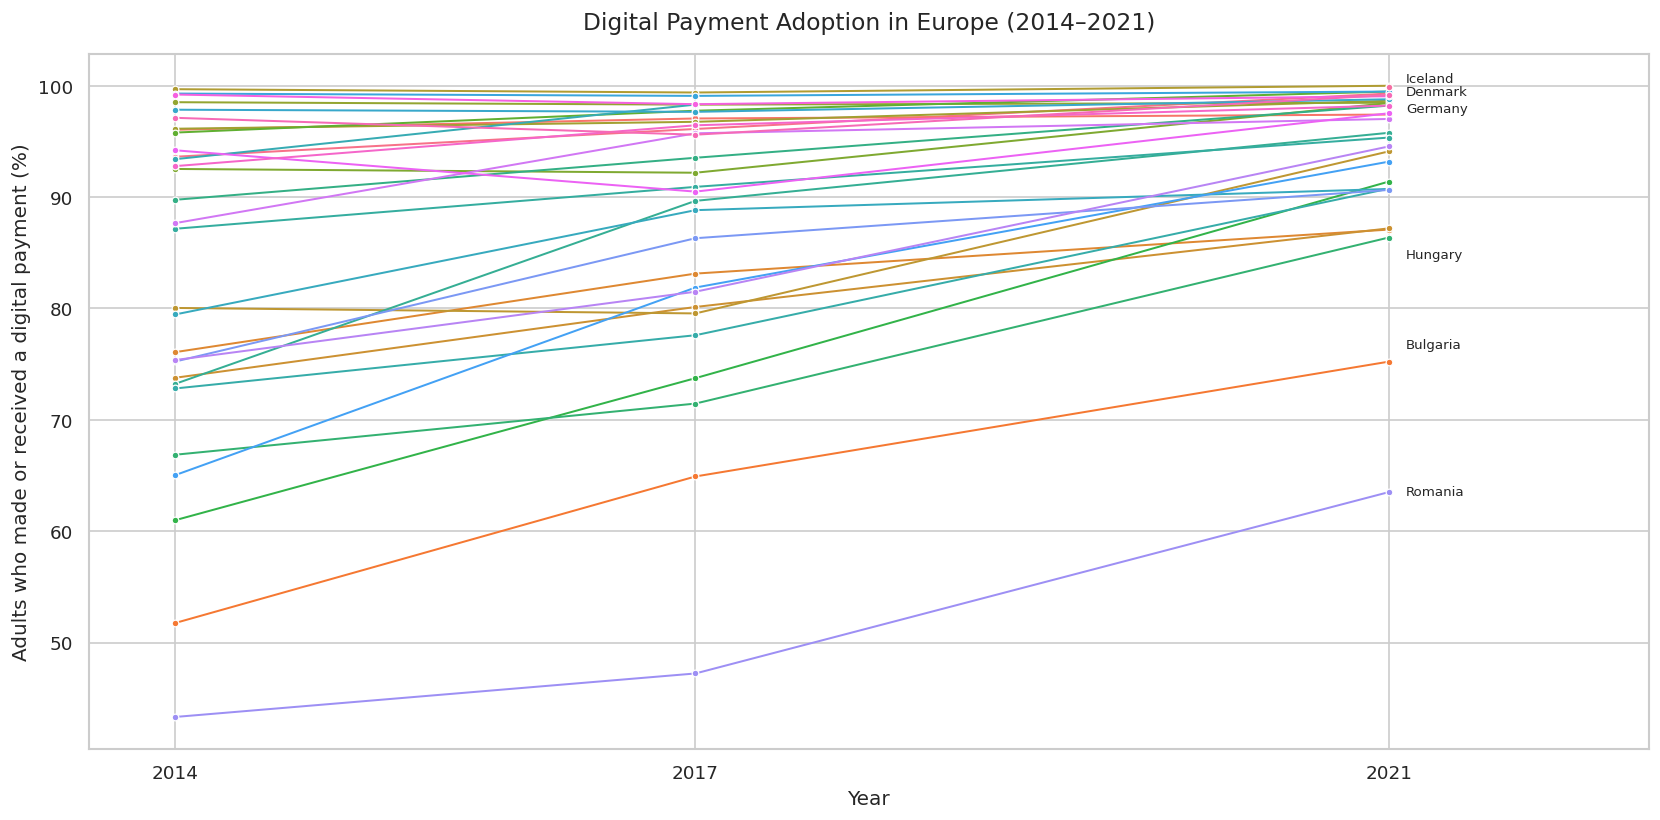

In [138]:
# Line chart: evolution of digital payment adoption across European countries
# Each line represents one country, x-axis shows the three available Findex waves

plt.figure(figsize=(14, 7))

sns.lineplot(
    data=df_trend,
    x="year",
    y="digital_payment_share",
    hue="country",
    marker="o",
    linewidth=1.2,
    markersize=4,
    legend=False
)

# Sort countries by 2021 value for label positioning
final_year = df_trend[df_trend["year"] == 2021].sort_values("digital_payment_share")

# Labels for bottom 3 countries — spaced 1.5 points apart to avoid overlap
bottom3 = final_year.head(3).reset_index(drop=True)
offsets_bottom = [0, 1.5, -1.5]
for i, row in bottom3.iterrows():
    plt.text(2021.1, row["digital_payment_share"] + offsets_bottom[i],
             row["country"], fontsize=8, va="center")

# Labels for top 3 countries — manually offset to separate overlapping lines
top3 = final_year.tail(3).reset_index(drop=True)
offsets_top = [-1.5, 0.8, -0.5]
for i, row in top3.iterrows():
    plt.text(2021.1, row["digital_payment_share"] + offsets_top[i],
             row["country"], fontsize=8, va="center")

plt.title("Digital Payment Adoption in Europe (2014–2021)", fontsize=14, pad=15)
plt.xlabel("Year")
plt.ylabel("Adults who made or received a digital payment (%)")
plt.xticks([2014, 2017, 2021])
plt.xlim(2013.5, 2022.5)   # extend the x-axis to the right to make room for the labels.
plt.tight_layout()
plt.show()

### 2.1 Country Ranking — 2021 Snapshot

The line chart shows the overall trajectory. The bar chart below focuses on 2021,
ranking all 31 countries by adoption rate to make cross-country comparison immediate.

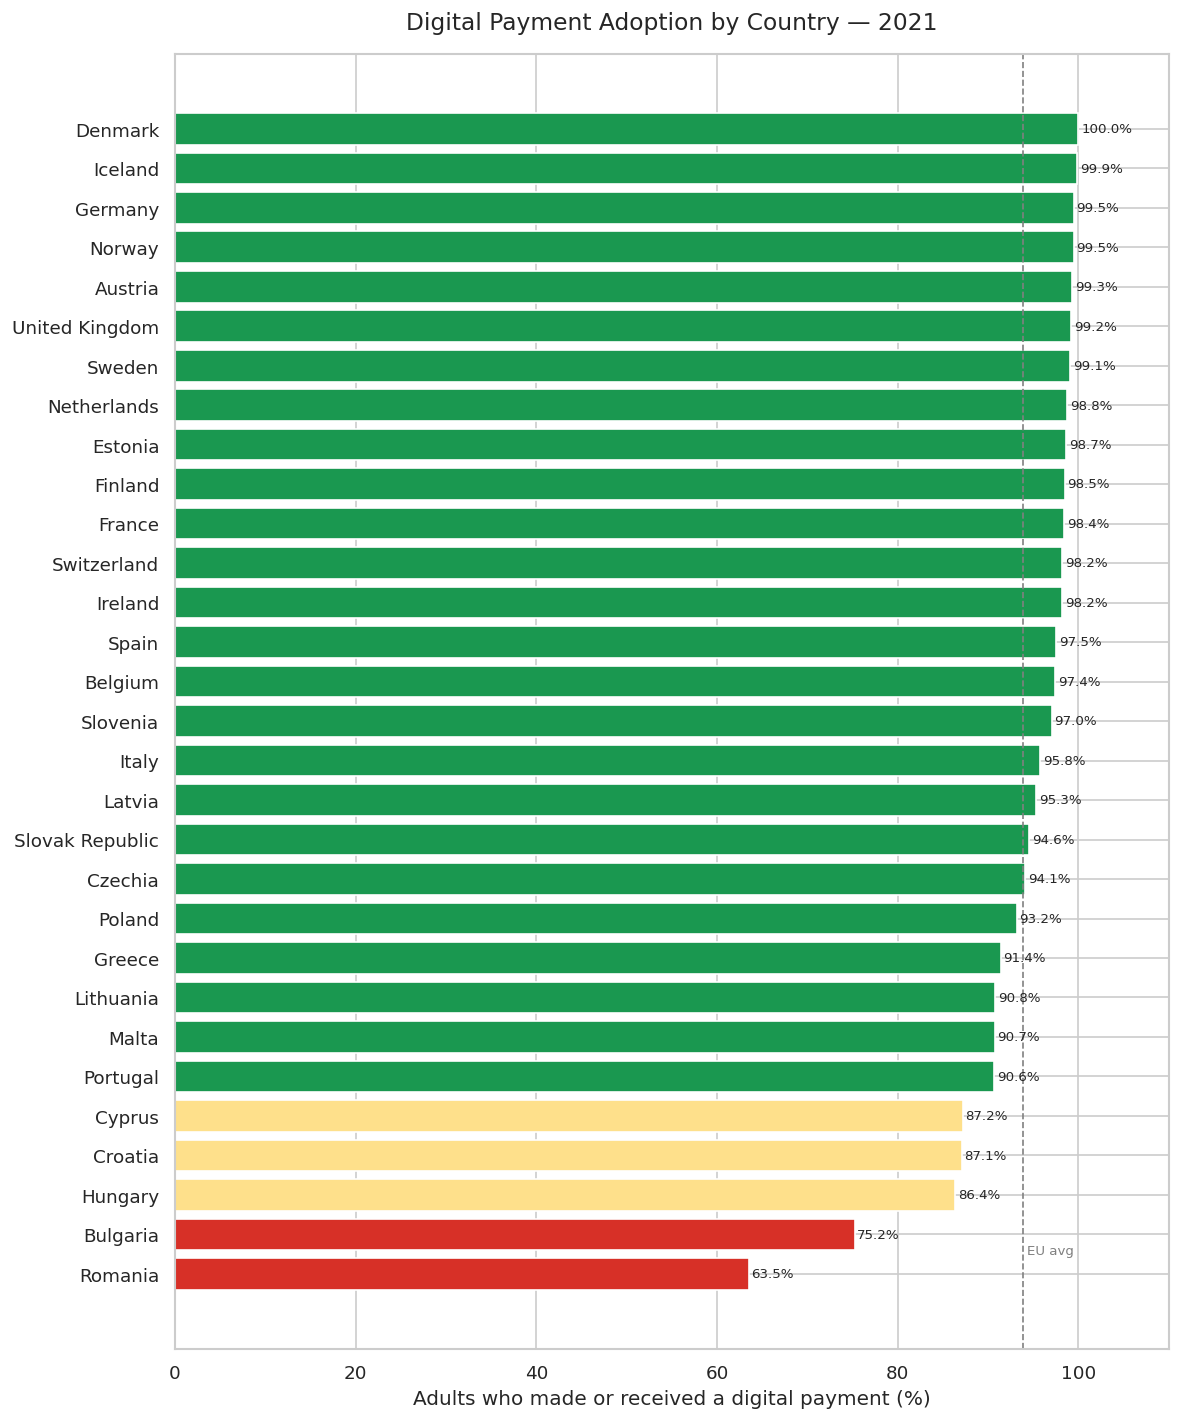

In [139]:
# Bar chart: country ranking by digital payment adoption in 2021
# Countries sorted from highest to lowest for immediate readability

df_2021 = df_trend[df_trend["year"] == 2021].sort_values(
    "digital_payment_share", ascending=True  # ascending=True for horizontal bar chart
)

plt.figure(figsize=(10, 12))

# Color bars by adoption level: green for high, red for low
colors = ["#d73027" if x < 80 else "#fee08b" if x < 90 else "#1a9850"
          for x in df_2021["digital_payment_share"]]

plt.barh(df_2021["country"], df_2021["digital_payment_share"], color=colors)

# Add value labels at the end of each bar
for i, (value, country) in enumerate(zip(df_2021["digital_payment_share"], df_2021["country"])):
    plt.text(value + 0.3, i, f"{value:.1f}%", va="center", fontsize=8)

plt.title("Digital Payment Adoption by Country — 2021", fontsize=14, pad=15)
plt.xlabel("Adults who made or received a digital payment (%)")
plt.xlim(0, 110)   # extra space on the right for value labels
plt.axvline(x=df_2021["digital_payment_share"].mean(),
            color="gray", linestyle="--", linewidth=1)  # European average line
plt.text(df_2021["digital_payment_share"].mean() + 0.5, 0.5,
         "EU avg", fontsize=8, color="gray")

plt.tight_layout()
plt.show()

### Key Takeaway — Part 2

Digital payment adoption in Europe has grown consistently across all 31 countries
between 2014 and 2021, with no country showing a decline. The European average rose
from 83.5% to 93.8% — a 10 percentage point increase in seven years.

The ranking reveals three distinct clusters:

- **Leaders (above 90%):** a large group of Northern, Western and Central European
countries where digital payments are effectively the norm
- **Mid-tier (80–90%):** a smaller group of Southern and Eastern European countries
still closing the gap
- **Laggards (below 80%):** Romania (63.5%) and Bulgaria (75.2%) stand out as clear
outliers, with adoption rates significantly below the European average

The gap between Denmark (100%) and Romania (63.5%) is 36 percentage points —
suggesting that geography, infrastructure and income level may all play a role.
Part 3 tests this hypothesis by correlating adoption rates with GDP per capita
and internet penetration.

## Part 3 — Correlation Analysis

**Question: does GDP per capita or internet penetration explain the variation
in digital payment adoption across European countries?**

Two additional datasets are introduced: World Bank GDP per capita and World Bank
internet penetration (% of individuals using the internet). Both are merged with
the digital payments dataset at country level for the year 2021.

In [140]:
# Load World Bank GDP per capita dataset
# The World Bank CSV format has 4 header rows before the actual data
df_gdp_raw = pd.read_csv(
    "/content/API_NY.GDP.PCAP.CD_DS2_en_csv_v2_121663.csv",
    skiprows=4
)

# Quick structure check
print("Dimensions:", df_gdp_raw.shape)
print("\nFirst columns:", df_gdp_raw.columns[:8].tolist())
df_gdp_raw.head(3)

Dimensions: (266, 71)

First columns: ['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '1960', '1961', '1962', '1963']


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,28440.041688,30082.158423,30645.890602,22759.807175,26749.329609,30975.998912,35718.753119,39498.594129,NaN,NaN
1,Africa Eastern and Southern,AFE,GDP per capita (current US$),NY.GDP.PCAP.CD,186.089204,186.909053,197.367547,225.400079,208.962717,226.836135,...,1528.104224,1552.073722,1507.085600,1351.591669,1562.416175,1679.327622,1571.449189,1615.396356,NaN,NaN
2,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,525.469771,491.337221,496.602504,510.787063,356.496214,357.261153,413.757895,NaN,NaN,NaN


In [141]:
# Extract GDP per capita for 2021 and filter to European countries
df_gdp = df_gdp_raw[["Country Code", "2021"]].copy()

# Rename columns for consistency with the main dataset
df_gdp = df_gdp.rename(columns={
    "Country Code": "country_code",
    "2021": "gdp_per_capita"
})

# Filter to European countries only
df_gdp = df_gdp[df_gdp["country_code"].isin(europe_countries)].copy()

print("European countries found:", len(df_gdp))
print("\nMissing values:", df_gdp["gdp_per_capita"].isna().sum())
print("\nSample:")
print(df_gdp.head(5))

European countries found: 31

Missing values: 0

Sample:
   country_code  gdp_per_capita
14          AUT    53648.643798
17          BEL    51658.238295
21          BGR    12966.145754
37          CHE    93664.773670
53          CYP    32937.839844


In [142]:
# Read World Bank internet penetration dataset into a dataframe
# Same wide format as GDP — 4 header rows to skip
df_internet_raw = pd.read_csv(
    "/content/API_IT.NET.USER.ZS_DS2_en_csv_v2_121585.csv",
    skiprows=4
)

# Extract 2021 values and filter to European countries
df_internet = df_internet_raw[["Country Code", "2021"]].copy()

df_internet = df_internet.rename(columns={
    "Country Code": "country_code",
    "2021": "internet_penetration"
})

df_internet = df_internet[df_internet["country_code"].isin(europe_countries)].copy()

print("European countries found:", len(df_internet))
print("\nMissing values:", df_internet["internet_penetration"].isna().sum())
print("\nSample:")
print(df_internet.head(5))

European countries found: 31

Missing values: 0

Sample:
   country_code  internet_penetration
14          AUT             92.529151
17          BEL             92.788676
21          BGR             75.271446
37          CHE             95.569372
53          CYP             90.759516


In [143]:
# Extract 2021 digital payment data for the correlation analysis
df_2021_clean = df_trend[df_trend["year"] == 2021][["country", "country_code", "digital_payment_share"]].copy()

# Merge digital payments with GDP per capita
df_corr = df_2021_clean.merge(df_gdp, on="country_code", how="left")

# Merge with internet penetration
df_corr = df_corr.merge(df_internet, on="country_code", how="left")

print("Dimensions after merge:", df_corr.shape)
print("\nMissing values:")
print(df_corr.isna().sum())
print("\nSample:")
df_corr.head(5)

Dimensions after merge: (30, 5)

Missing values:
country                  0
country_code             0
digital_payment_share    0
gdp_per_capita           0
internet_penetration     0
dtype: int64

Sample:


,country,country_code,digital_payment_share,gdp_per_capita,internet_penetration
0,Austria,AUT,99.300150,53648.643798,92.529151
1,Belgium,BEL,97.414604,51658.238295,92.788676
2,Bulgaria,BGR,75.225908,12966.145754,75.271446
3,Croatia,HRV,87.084610,17788.786582,81.253966
4,Cyprus,CYP,87.194105,32937.839844,90.759516


In [144]:
# Identify which country was lost in the merge
# by comparing the country codes in df_2021_clean with those in df_corr
codes_before = set(df_trend[df_trend["year"] == 2021]["country_code"].unique())
codes_after = set(df_corr["country_code"].unique())

print("Country missing after merge:")
print(codes_before - codes_after)

Country missing after merge:
set()


In [145]:
# Check which country from the original European list
# has no data in the 2021 Findex wave
codes_europe = set(europe_countries)
codes_2021 = set(df_trend[df_trend["year"] == 2021]["country_code"].unique())

print("Country with no Findex data in 2021:")
print(codes_europe - codes_2021)

Country with no Findex data in 2021:
{'LUX'}


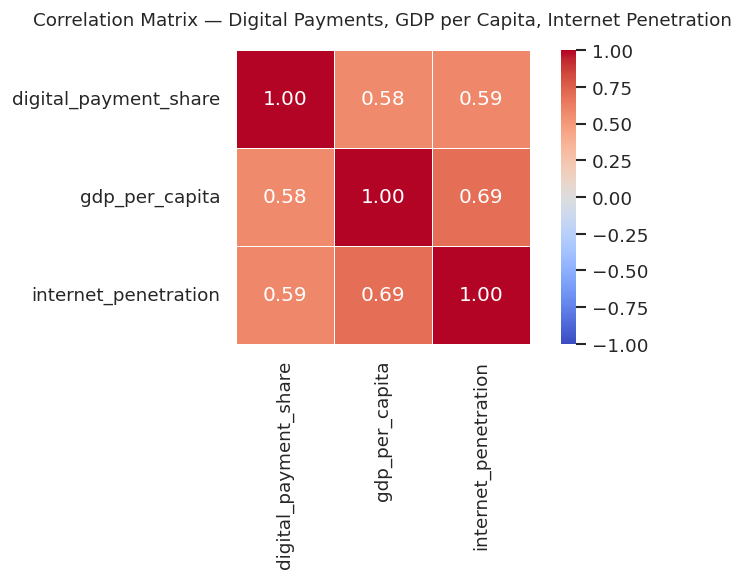

In [146]:
# Correlation heatmap between digital payment adoption, GDP per capita
# and internet penetration
# Only the three numeric columns are used

df_corr_matrix = df_corr[["digital_payment_share", "gdp_per_capita", "internet_penetration"]].corr()

plt.figure(figsize=(7, 5))

sns.heatmap(
    df_corr_matrix,
    annot=True,           # show correlation values inside each cell
    fmt=".2f",            # two decimal places
    cmap="coolwarm",      # red for negative, blue for positive correlation
    vmin=-1, vmax=1,      # fix scale to full correlation range
    square=True,          # square cells for readability
    linewidths=0.5        # thin lines between cells
)

plt.title("Correlation Matrix — Digital Payments, GDP per Capita, Internet Penetration",
          fontsize=11, pad=15)
plt.tight_layout()
plt.show()

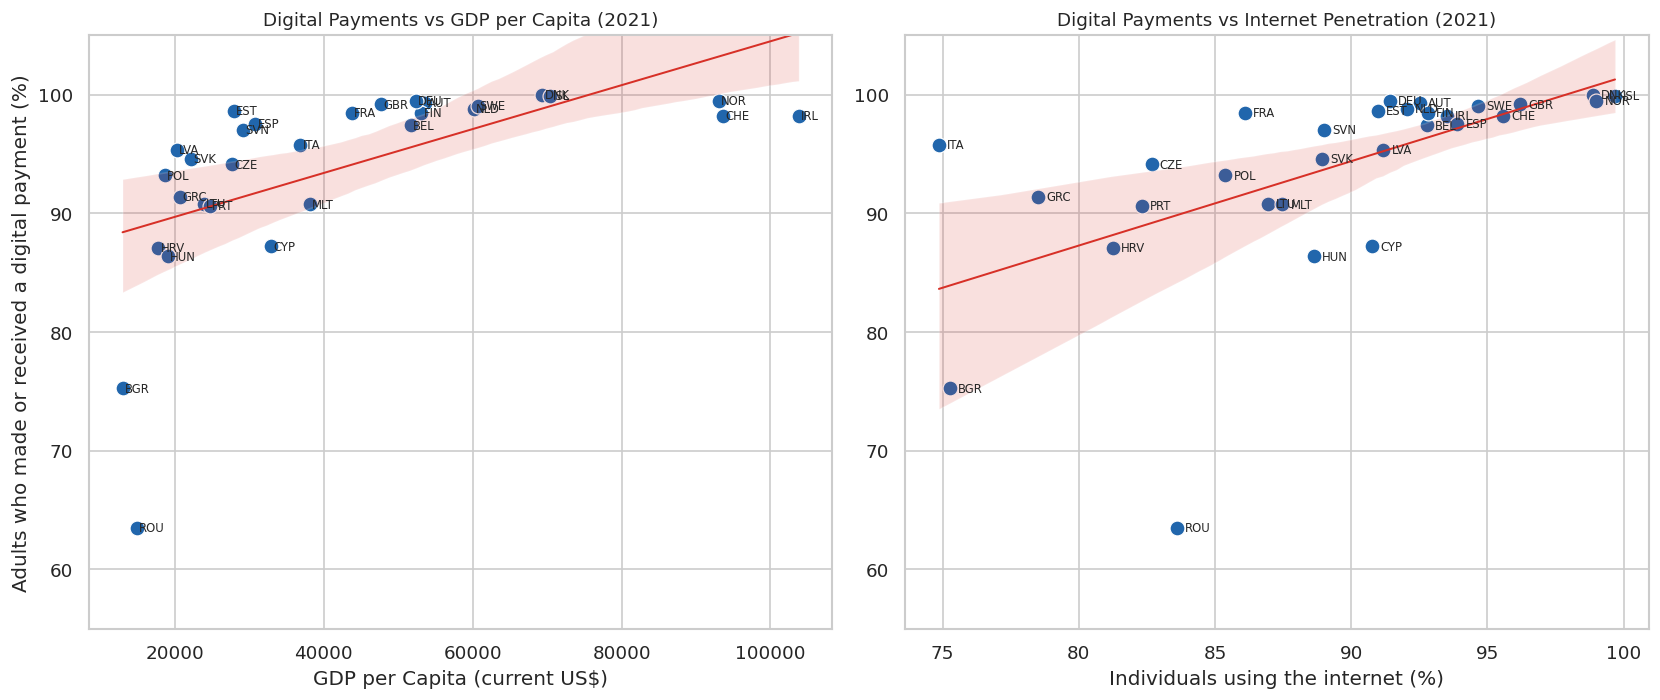

In [147]:
# Scatter plots: digital payment adoption vs GDP per capita and internet penetration
# Side by side for direct comparison

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left plot: digital payments vs GDP per capita
sns.scatterplot(
    data=df_corr,
    x="gdp_per_capita",
    y="digital_payment_share",
    ax=axes[0],
    color="#2166ac",
    s=80
)

for _, row in df_corr.iterrows():
    axes[0].text(
        row["gdp_per_capita"] + 300,
        row["digital_payment_share"],
        row["country_code"],
        fontsize=7, va="center"
    )

sns.regplot(
    data=df_corr,
    x="gdp_per_capita",
    y="digital_payment_share",
    ax=axes[0],
    scatter=False,
    color="#d73027",
    line_kws={"linewidth": 1.2}
)

axes[0].set_title("Digital Payments vs GDP per Capita (2021)", fontsize=11)
axes[0].set_xlabel("GDP per Capita (current US$)")
axes[0].set_ylabel("Adults who made or received a digital payment (%)")
axes[0].set_ylim(55, 105)    # fix y axis to a valid percentage range

# Right plot: digital payments vs internet penetration
sns.scatterplot(
    data=df_corr,
    x="internet_penetration",
    y="digital_payment_share",
    ax=axes[1],
    color="#2166ac",
    s=80
)

for _, row in df_corr.iterrows():
    axes[1].text(
        row["internet_penetration"] + 0.3,
        row["digital_payment_share"],
        row["country_code"],
        fontsize=7, va="center"
    )

sns.regplot(
    data=df_corr,
    x="internet_penetration",
    y="digital_payment_share",
    ax=axes[1],
    scatter=False,
    color="#d73027",
    line_kws={"linewidth": 1.2}
)

axes[1].set_title("Digital Payments vs Internet Penetration (2021)", fontsize=11)
axes[1].set_xlabel("Individuals using the internet (%)")
axes[1].set_ylabel("")
axes[1].set_ylim(55, 105)    # fix y axis to a valid percentage range

plt.tight_layout()
plt.show()

### Key Takeaway — Part 3

Both GDP per capita and internet penetration show a moderate positive correlation
with digital payment adoption (r = 0.58 and r = 0.59 respectively). Wealthier
countries and those with higher internet access tend to have higher adoption rates.

However, the correlation is far from perfect. Several countries — notably Italy —
show adoption rates above 95% despite mid-range GDP levels, while Romania sits at
63.5% adoption despite having 84% internet penetration. This suggests that income
and connectivity are enablers, but not sufficient conditions on their own.

Other factors — such as banking infrastructure, regulatory environment, consumer
trust, and cultural attitudes toward cash — likely explain the residual variation.
Part 4 groups countries into clusters based on their payment profile to explore
these patterns further.

## Part 4 — Clustering Analysis

**Question: are there distinct groups of European countries with similar digital
payment profiles, and what characterises each group?**

K-means clustering is applied to group the 30 European countries based on three
variables: digital payment adoption, GDP per capita, and internet penetration.
The optimal number of clusters is selected using the elbow method.

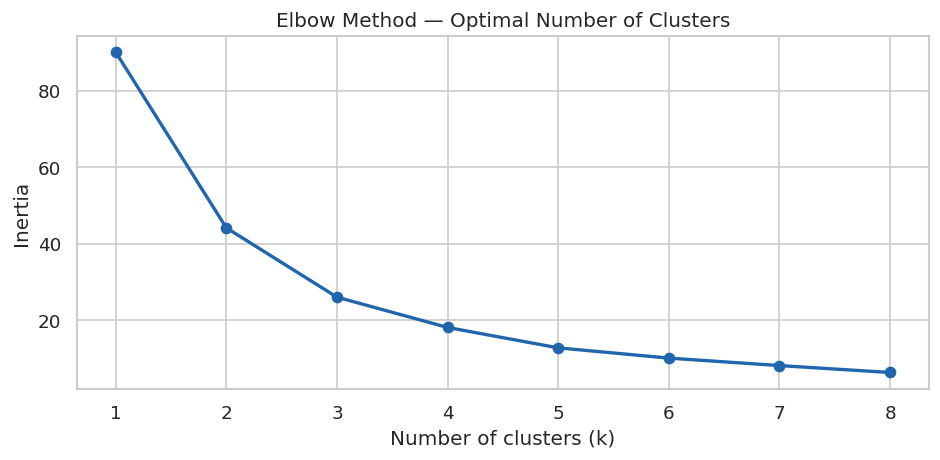

In [148]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# K-means requires standardized features — otherwise GDP per capita (in thousands)
# would dominate the clustering due to its larger scale
scaler = StandardScaler()
features = ["digital_payment_share", "gdp_per_capita", "internet_penetration"]
X = scaler.fit_transform(df_corr[features])

# Elbow method: compute inertia for k=1 to k=8
# Inertia measures how compact the clusters are — lower is better
inertia = []
k_range = range(1, 9)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker="o", color="#2166ac", linewidth=2)
plt.title("Elbow Method — Optimal Number of Clusters", fontsize=12)
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.xticks(k_range)
plt.tight_layout()
plt.show()

### Choosing the Number of Clusters

The elbow curve shows a significant drop in inertia from k=1 to k=3, after which
the descent flattens noticeably. **k=3 is selected** as the optimal number of
clusters: it captures the main structure in the data while remaining interpretable
from a business perspective.

In [149]:
# Apply K-means clustering with k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_corr["cluster"] = kmeans.fit_predict(X)

# Print cluster composition to interpret each group
for cluster_id in sorted(df_corr["cluster"].unique()):
    countries = df_corr[df_corr["cluster"] == cluster_id]["country"].tolist()
    avg_payments = df_corr[df_corr["cluster"] == cluster_id]["digital_payment_share"].mean()
    avg_gdp = df_corr[df_corr["cluster"] == cluster_id]["gdp_per_capita"].mean()
    avg_internet = df_corr[df_corr["cluster"] == cluster_id]["internet_penetration"].mean()
    print(f"\nCluster {cluster_id} — {len(countries)} countries")
    print(f"  Avg digital payments: {avg_payments:.1f}%")
    print(f"  Avg GDP per capita:   ${avg_gdp:,.0f}")
    print(f"  Avg internet:         {avg_internet:.1f}%")
    print(f"  Countries: {', '.join(countries)}")


Cluster 0 — 16 countries
  Avg digital payments: 93.0%
  Avg GDP per capita:   $27,146
  Avg internet:         86.2%
  Countries: Croatia, Cyprus, Czechia, Estonia, France, Greece, Hungary, Italy, Latvia, Lithuania, Malta, Poland, Portugal, Slovak Republic, Slovenia, Spain

Cluster 1 — 12 countries
  Avg digital payments: 99.0%
  Avg GDP per capita:   $67,460
  Avg internet:         94.9%
  Countries: Austria, Belgium, Denmark, Finland, Germany, Iceland, Ireland, Netherlands, Norway, Sweden, Switzerland, United Kingdom

Cluster 2 — 2 countries
  Avg digital payments: 69.4%
  Avg GDP per capita:   $13,937
  Avg internet:         79.4%
  Countries: Bulgaria, Romania


### Cluster Profiles

Three distinct groups emerge from the analysis:

- **Cluster 1 — Mature Markets** (12 countries): high-income Western and Northern
European countries with near-universal digital payment adoption (avg 99.0%) and
the highest GDP per capita (avg $67,460). Digital payments are effectively the norm.

- **Cluster 0 — Growing Markets** (16 countries): a large and diverse group of
Central, Eastern and Southern European countries with solid adoption (avg 93.0%)
but significantly lower income levels (avg $27,146). The infrastructure is in place
but economic development lags behind.

- **Cluster 2 — Emerging Markets** (2 countries): Bulgaria and Romania stand apart
on all three dimensions — lower adoption (avg 69.4%), lower GDP (avg $13,937) and
lower internet penetration (avg 79.4%). These are the markets with the most headroom
for growth.

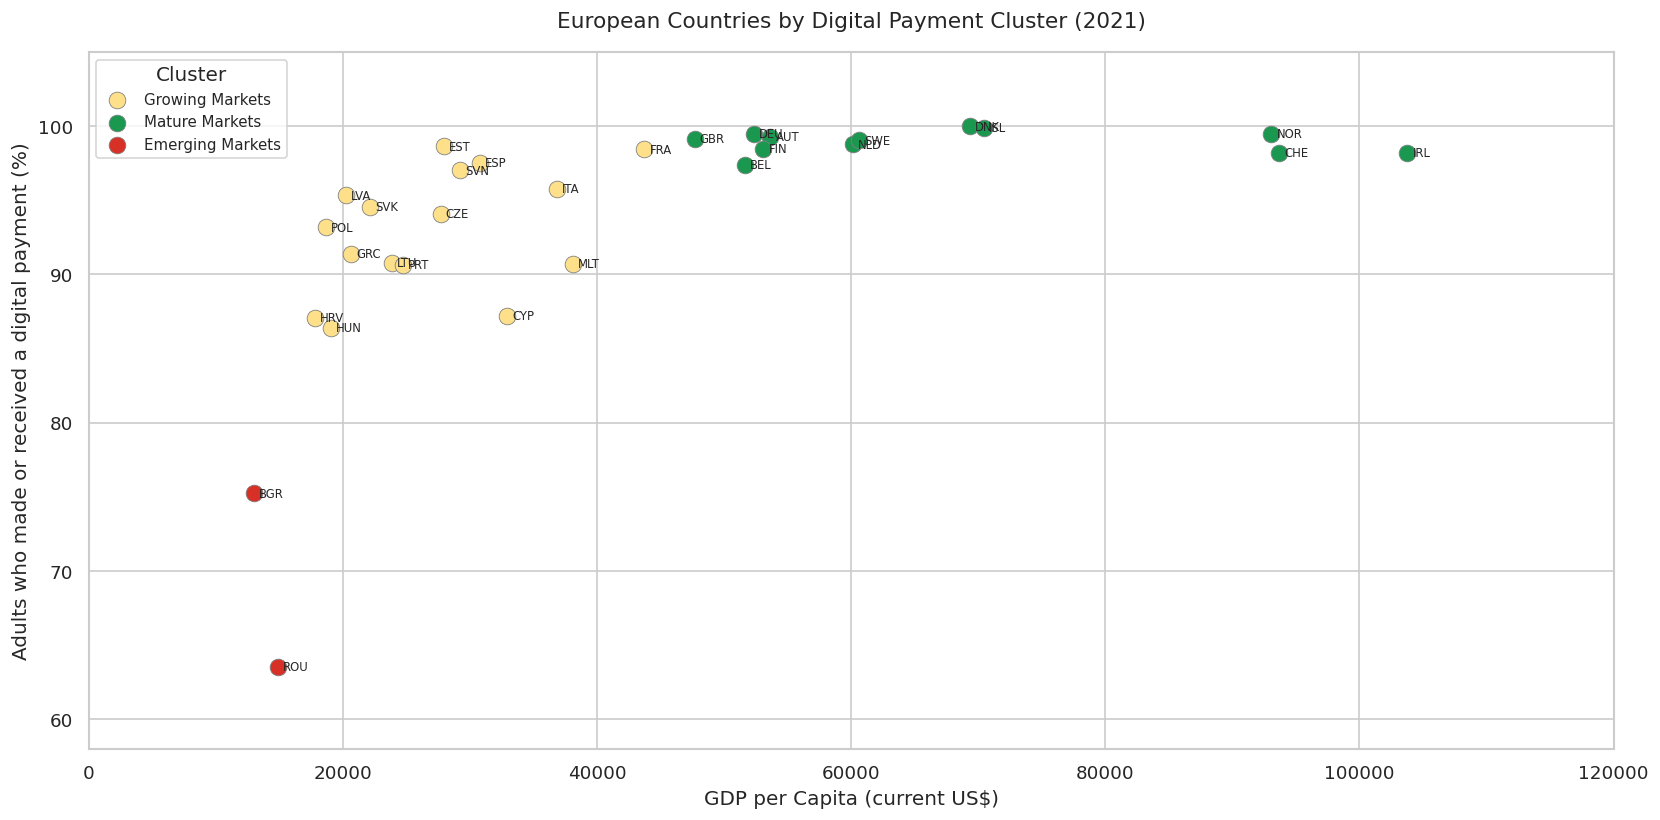

In [150]:
# Scatter plot: cluster visualization using digital payments vs GDP per capita
# Color-coded by cluster, with country labels

cluster_colors = {0: "#fee08b", 1: "#1a9850", 2: "#d73027"}
cluster_labels = {0: "Growing Markets", 1: "Mature Markets", 2: "Emerging Markets"}

plt.figure(figsize=(14, 7))

for cluster_id in sorted(df_corr["cluster"].unique()):
    subset = df_corr[df_corr["cluster"] == cluster_id]
    plt.scatter(
        subset["gdp_per_capita"],
        subset["digital_payment_share"],
        color=cluster_colors[cluster_id],
        label=cluster_labels[cluster_id],
        s=100,
        edgecolors="gray",
        linewidths=0.5
    )
    for _, row in subset.iterrows():
        plt.text(
            row["gdp_per_capita"] + 400,
            row["digital_payment_share"],
            row["country_code"],
            fontsize=7, va="center"
        )

plt.title("European Countries by Digital Payment Cluster (2021)", fontsize=13, pad=15)
plt.xlabel("GDP per Capita (current US$)")
plt.ylabel("Adults who made or received a digital payment (%)")
plt.ylim(58, 105)       # extended downward to show Romania fully
plt.xlim(0, 120000)     # extended rightward to show Ireland fully
plt.legend(title="Cluster", fontsize=9)
plt.tight_layout()
plt.show()

### Key Takeaway — Part 4

K-means clustering confirms the three-tier structure suggested by the earlier
visualizations:

- **Mature Markets** (Austria, Belgium, Denmark, Finland, Germany, Iceland, Ireland,
Netherlands, Norway, Sweden, Switzerland, United Kingdom): near-universal adoption,
high income, high connectivity. Limited growth potential for new entrants —
competition is the main challenge.

- **Growing Markets** (16 countries across Central, Eastern and Southern Europe):
solid adoption rates but lower income levels. Infrastructure is in place; the
opportunity lies in increasing transaction frequency and ticket size rather than
basic adoption.

- **Emerging Markets** (Bulgaria, Romania): the lowest adoption, income and internet
penetration in the sample. High growth potential but structural barriers —
infrastructure gaps, lower digital literacy, and cash-dominant cultures — require
a different market entry approach.

The cluster structure is driven by a combination of all three variables, confirming
that digital payment adoption is not explained by income or connectivity alone.

## Part 5 — Actionable Conclusions

**Question: what do these findings mean for a fintech looking to expand in Europe?**

The analysis points to three distinct strategic opportunities depending on the
target market. The following conclusions are structured as a strategic briefing
for a product team evaluating European market entry or expansion priorities.

### Strategic Briefing — Digital Payments in Europe

#### 1. The European market is mature but uneven
Digital payment adoption averages 93.8% across Europe, but the gap between Denmark
(100%) and Romania (63.5%) is 36 percentage points. A single pan-European strategy
is unlikely to work — market entry decisions should be cluster-aware.

#### 2. Mature Markets: compete on product, not adoption
In the 12 Mature Market countries, cash is already largely irrelevant. The battle
is not about convincing people to go digital — it is about winning share from
established players. A fintech entering Germany, the Netherlands or the Nordics
needs a compelling product differentiator: better UX, lower fees, embedded finance,
or a specific vertical (e.g. B2B payments, cross-border transfers).

#### 3. Growing Markets: the highest risk-adjusted opportunity
The 16 Growing Market countries represent the most attractive expansion target for
most fintechs. Adoption is already above 90% on average, meaning the infrastructure
and consumer readiness are in place. GDP per capita is lower, but so is competitive
intensity. Countries like Poland, Czechia and the Baltics combine solid digital
infrastructure with underserved fintech markets — making them natural beachheads
for European expansion.

#### 4. Emerging Markets: high potential, high barriers
Bulgaria and Romania have the most headroom for adoption growth, but also the most
structural barriers: lower internet penetration, lower income levels, and deeply
rooted cash cultures. Market entry here requires a longer investment horizon,
localised product strategies, and potentially partnerships with local banks or
telecoms to reach underserved populations.

#### 5. Internet penetration matters as much as income
The correlation analysis shows that internet penetration (r=0.59) explains adoption
as well as GDP per capita (r=0.58). This has a practical implication: as mobile
infrastructure continues to improve in Eastern Europe, adoption in Growing and
Emerging Markets is likely to accelerate — making early entry more valuable than
it might appear today.

---
*Data sources: World Bank Global Findex Database 2025, World Bank GDP per capita
(NY.GDP.PCAP.CD), World Bank Internet penetration (IT.NET.USER.ZS).
Analysis covers 30 European countries (EU27 + UK + Norway + Switzerland + Iceland,
excluding Luxembourg due to missing Findex data). Reference year: 2021.*